## Cell 1 — Install Dependencies

In [ ]:
!pip install -q datasets transformers rouge-score git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


## Cell 2 — Imports

In [ ]:
import os, random, math, numpy as np, torch, torch.nn as nn, clip, nltk
from PIL import Image
from collections import Counter
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.models as models
import torchvision.transforms as T
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
import matplotlib.pyplot as plt

nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
print('CLIP loaded.')

Device: cuda


100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 357MiB/s]


CLIP loaded.


## Cell 3 — Load Flickr8k

In [ ]:
dataset = load_dataset('jxie/flickr8k')

train_data   = dataset['train']
val_data     = dataset['test']
CAPTION_KEYS = ['caption_0','caption_1','caption_2','caption_3','caption_4']

print(f'Train: {len(train_data)} | Val: {len(val_data)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 6000 | Val: 1000


## Cell 4 — Vocabulary

In [ ]:
def build_vocab(hf_split, caption_keys=CAPTION_KEYS, min_freq=3):
    counter = Counter()
    for item in hf_split:
        for key in caption_keys:
            counter.update(item[key].lower().split())
    vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab    = build_vocab(train_data)
idx2word = {v: k for k, v in vocab.items()}
print(f'Vocab size: {len(vocab)}')

Vocab size: 3498


## Cell 5 — Dataset & DataLoader

In [ ]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

class Flickr8kDataset(Dataset):
    def __init__(self, hf_split, vocab, transform=None,
                 caption_keys=CAPTION_KEYS):
        self.vocab     = vocab
        self.transform = transform
        self.samples   = []
        for item in hf_split:
            for key in caption_keys:
                self.samples.append((item['image'], item[key]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        image, caption = self.samples[idx]
        image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        tokens = (
            [self.vocab['<SOS>']] +
            [self.vocab.get(w, self.vocab['<UNK>']) for w in caption.lower().split()] +
            [self.vocab['<EOS>']]
        )
        return image, torch.tensor(tokens)

def collate_fn(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images)
    captions = pad_sequence(captions, batch_first=True, padding_value=0)
    return images, captions

train_dataset = Flickr8kDataset(train_data, vocab, transform)
val_dataset   = Flickr8kDataset(val_data,   vocab, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f'Train pairs: {len(train_dataset)} | Val pairs: {len(val_dataset)}')

Train pairs: 30000 | Val pairs: 5000


## Cell 6 — Precompute CNN Features

In [ ]:
import torch.nn.functional as F

EMBED_SIZE  = 512
FEATURE_DIM = 2048

for f in ['train_feats.pt', 'val_feats.pt', 'best_transformer.pt']:
    if os.path.exists(f):
        os.remove(f); print(f'Deleted {f}')

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            feats = self.backbone(images)          # (B, 2048, 7, 7)
        B, C, H, W = feats.shape
        feats = feats.permute(0, 2, 3, 1)          # (B, 7, 7, 2048)
        feats = feats.reshape(B, H*W, C)           # (B, 49, 2048)
        return feats

encoder = CNNEncoder().to(device)

def precompute_features(encoder, loader, device, save_path):
    if os.path.exists(save_path):
        print(f'Loading {save_path}...')
        return torch.load(save_path)
    encoder.eval()
    all_feats, all_caps = [], []
    with torch.no_grad():
        for images, captions in loader:
            feats = encoder(images.to(device))
            all_feats.append(feats.cpu())
            all_caps.append(captions)
    max_len     = max(c.size(1) for c in all_caps)
    padded_caps = [F.pad(c, (0, max_len - c.size(1))) for c in all_caps]
    data = {'features': torch.cat(all_feats), 'captions': torch.cat(padded_caps)}
    torch.save(data, save_path)
    print(f'Saved -> {save_path}  features: {data["features"].shape}')
    return data

train_cache = precompute_features(encoder, train_loader, device, 'train_feats.pt')
val_cache   = precompute_features(encoder, val_loader,   device, 'val_feats.pt')

class FeatureDataset(Dataset):
    def __init__(self, cache):
        self.features = cache['features']
        self.captions = cache['captions']
    def __len__(self): return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.captions[idx]

train_feat_loader = DataLoader(FeatureDataset(train_cache), batch_size=64,
                               shuffle=True,  num_workers=2)
val_feat_loader   = DataLoader(FeatureDataset(val_cache),   batch_size=64,
                               shuffle=False, num_workers=2)

print('Feature datasets ready.')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 244MB/s]


Saved -> train_feats.pt  features: torch.Size([30000, 49, 2048])
Saved -> val_feats.pt  features: torch.Size([5000, 49, 2048])
Feature datasets ready.


## Cell 7 — Transformer Decoder

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe           = torch.zeros(max_len, embed_size)
        pos          = torch.arange(0, max_len).unsqueeze(1).float()
        div          = torch.exp(
            torch.arange(0, embed_size, 2).float() * (-math.log(10000.0) / embed_size)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size=512, num_heads=8,
                 num_layers=4, ff_dim=2048, dropout=0.1,
                 feature_dim=2048, max_len=256):
        super().__init__()
        self.embed        = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.feature_proj = nn.Linear(feature_dim, embed_size)
        self.pos_enc      = PositionalEncoding(embed_size, max_len, dropout)
        decoder_layer     = nn.TransformerDecoderLayer(
            d_model=embed_size, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer  = nn.TransformerDecoder(decoder_layer, num_layers)
        self.linear       = nn.Linear(embed_size, vocab_size)
        self.embed_size   = embed_size
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, features, captions):
        memory   = self.feature_proj(features)
        tgt      = captions[:, :-1]
        tgt_emb  = self.pos_enc(self.embed(tgt))
        T        = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(features.device)
        tgt_key_padding_mask = (tgt == 0)
        out      = self.transformer(
            tgt        = tgt_emb,
            memory     = memory,
            tgt_mask   = tgt_mask,
            tgt_key_padding_mask = tgt_key_padding_mask
        )
        return self.linear(out)


decoder   = TransformerDecoder(
    vocab_size  = len(vocab),
    embed_size  = EMBED_SIZE,
    num_heads   = 8,
    num_layers  = 4,
    ff_dim      = 2048,
    dropout     = 0.1,
    feature_dim = FEATURE_DIM
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(decoder.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

total = sum(p.numel() for p in decoder.parameters())
print(f'Transformer decoder parameters: {total:,}')

Transformer decoder parameters: 21,450,666


## Cell 8 — Training Loop

In [ ]:
from torch.amp import autocast, GradScaler

NUM_EPOCHS   = 30
LOG_INTERVAL = 100
scaler       = GradScaler('cuda')

def train_epoch(decoder, loader, optimizer, scaler, device, epoch):
    decoder.train()
    total_loss = running_loss = 0
    for i, (features, captions) in enumerate(loader, 1):
        features, captions = features.to(device), captions.to(device)
        with autocast('cuda'):
            outputs = decoder(features, captions)
            loss    = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                captions[:, 1:].reshape(-1)
            )
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5)
        scaler.step(optimizer)
        scaler.update()
        total_loss   += loss.item()
        running_loss += loss.item()
        if i % LOG_INTERVAL == 0:
            print(f'  Epoch {epoch} | Batch [{i}/{len(loader)}] | '
                  f'Loss: {running_loss/LOG_INTERVAL:.4f}')
            running_loss = 0
    return total_loss / len(loader)

def val_epoch(decoder, loader, device):
    decoder.eval(); total_loss = 0
    with torch.no_grad():
        for features, captions in loader:
            features, captions = features.to(device), captions.to(device)
            with autocast('cuda'):
                outputs = decoder(features, captions)
                loss    = criterion(
                    outputs.reshape(-1, outputs.size(-1)),
                    captions[:, 1:].reshape(-1)
                )
            total_loss += loss.item()
    return total_loss / len(loader)

best_val_loss = float('inf')
history       = {'train': [], 'val': []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{NUM_EPOCHS} ---')
    train_loss = train_epoch(decoder, train_feat_loader, optimizer, scaler, device, epoch)
    print('  Validating...')
    val_loss   = val_epoch(decoder, val_feat_loader, device)
    scheduler.step(val_loss)
    history['train'].append(train_loss)
    history['val'].append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(decoder.state_dict(), 'best_transformer.pt')
        print(f'  *** Saved checkpoint ***')
    print(f'  Train: {train_loss:.4f}  Val: {val_loss:.4f}  '
          f'LR: {optimizer.param_groups[0]["lr"]:.2e}')

print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Best epoch    : {history["val"].index(min(history["val"])) + 1}')


--- Epoch 1/30 ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  Epoch 1 | Batch [100/469] | Loss: 5.1258
  Epoch 1 | Batch [200/469] | Loss: 4.3785
  Epoch 1 | Batch [300/469] | Loss: 4.0589
  Epoch 1 | Batch [400/469] | Loss: 3.7104
  Validating...
  *** Saved checkpoint ***
  Train: 4.2008  Val: 3.3938  LR: 3.00e-04

--- Epoch 2/30 ---
  Epoch 2 | Batch [100/469] | Loss: 3.2736
  Epoch 2 | Batch [200/469] | Loss: 3.1692
  Epoch 2 | Batch [300/469] | Loss: 3.0779
  Epoch 2 | Batch [400/469] | Loss: 3.0002
  Validating...
  *** Saved checkpoint ***
  Train: 3.1043  Val: 2.9639  LR: 3.00e-04

--- Epoch 3/30 ---
  Epoch 3 | Batch [100/469] | Loss: 2.7958
  Epoch 3 | Batch [200/469] | Loss: 2.7521
  Epoch 3 | Batch [300/469] | Loss: 2.7298
  Epoch 3 | Batch [400/469] | Loss: 2.7070
  Validating...
  *** Saved checkpoint ***
  Train: 2.7378  Val: 2.8497  LR: 3.00e-04

--- Epoch 4/30 ---
  Epoch 4 | Batch [100/469] | Loss: 2.5003
  Epoch 4 | Batch [200/469] | Loss: 2.5128
  Epoch 4 | Batch [300/469] | Loss: 2.5123
  Epoch 4 | Batch [400/469] | Loss: 2

## Cell 9 — Beam Search + CLIP Reranking

In [ ]:
def compute_clip_score(image_pil, caption, clip_model, clip_preprocess, device):
    image_input = clip_preprocess(image_pil).unsqueeze(0).to(device)
    text_input  = clip.tokenize([caption], truncate=True).to(device)
    with torch.no_grad():
        img_feat = clip_model.encode_image(image_input)
        txt_feat = clip_model.encode_text(text_input)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
    return max(2.5 * (img_feat @ txt_feat.T).item(), 0)


def get_banned_tokens(tokens, no_repeat_ngram_size=3):
    """Returns set of token ids that would create a repeated n-gram."""
    if len(tokens) < no_repeat_ngram_size:
        return set()
    banned = set()
    ngram_size = no_repeat_ngram_size
    # Get the last (ngram_size-1) tokens as the current context
    context = tuple(tokens[-(ngram_size - 1):])
    # Find all previous occurrences of this context
    for i in range(len(tokens) - ngram_size + 1):
        if tuple(tokens[i:i + ngram_size - 1]) == context:
            banned.add(tokens[i + ngram_size - 1])
    return banned


def beam_search(decoder, feature, vocab, idx2word,
                beam_size=5, max_len=25, no_repeat_ngram=3,
                length_penalty=0.9, device='cuda'):
    decoder.eval()
    feature   = feature.unsqueeze(0).to(device)
    memory    = decoder.feature_proj(feature)
    beams     = [(0.0, [vocab['<SOS>']])]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []
            for score, tokens in beams:
                if tokens[-1] == vocab['<EOS>']:
                    completed.append((score, tokens)); continue

                tgt      = torch.tensor([tokens], device=device)
                tgt_emb  = decoder.pos_enc(decoder.embed(tgt))
                T        = tgt.size(1)
                mask     = nn.Transformer.generate_square_subsequent_mask(T).to(device)
                out      = decoder.transformer(tgt_emb, memory, tgt_mask=mask)
                logprobs = torch.log_softmax(decoder.linear(out[:, -1, :]), dim=-1)

                # Block tokens that would create repeated n-grams
                banned = get_banned_tokens(tokens, no_repeat_ngram)
                for b in banned:
                    logprobs[0, b] = float('-inf')

                # Block <UNK>
                logprobs[0, vocab['<UNK>']] = float('-inf')

                topk_p, topk_i = logprobs.topk(beam_size)
                for p, idx in zip(topk_p[0], topk_i[0]):
                    new_score = score + p.item()
                    new_beams.append((new_score, tokens + [idx.item()]))

            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

        completed += [(s, t) for s, t in beams]

    results = []
    for score, tokens in sorted(completed, key=lambda x: x[0], reverse=True):
        words = [idx2word[t] for t in tokens
                 if t not in {vocab['<SOS>'], vocab['<EOS>'], vocab['<PAD>']}]
        # Apply length penalty to favour more complete sentences
        caption      = ' '.join(words)
        length       = max(len(words), 1)
        penalised    = score / (length ** length_penalty)
        results.append((caption, penalised))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


def postprocess(caption):
    import re
    # Remove everything after a quote mark — model sometimes hallucinates quoted fragments
    caption = caption.split('"')[0].strip()
    # Remove trailing punctuation
    caption = re.sub(r'[\s.,"\'-]+$', '', caption).strip()
    # Remove consecutive duplicate words e.g. "of of", "sand sand"
    words   = caption.split()
    cleaned = [words[0]] if words else []
    for w in words[1:]:
        if w != cleaned[-1]:
            cleaned.append(w)
    caption = ' '.join(cleaned)
    # If last word is a preposition or article, chop it
    stopwords = {'of', 'a', 'an', 'the', 'in', 'on', 'at', 'with',
                 'and', 'or', 'to', 'by', 'for', 'from', 'other'}
    words = caption.split()
    while words and words[-1].lower() in stopwords:
        words.pop()
    return ' '.join(words).strip()


def generate_caption(decoder, encoder, image_pil, vocab, idx2word,
                     clip_model, clip_preprocess,
                     beam_size=10, max_len=30, device='cuda'):  # beam_size 5->10
    image      = transform(image_pil.convert('RGB')).unsqueeze(0).to(device)
    feature    = encoder(image).squeeze(0)
    candidates = beam_search(decoder, feature, vocab, idx2word,
                             beam_size, max_len, device=device)
    candidates = [(postprocess(c), s) for c, s in candidates
              if len(postprocess(c).split()) >= 6]
    if not candidates:
        return '', []
    captions_only = [c for c, _ in candidates]
    scores        = [compute_clip_score(image_pil, c, clip_model,
                                        clip_preprocess, device)
                     for c in captions_only]
    best = captions_only[scores.index(max(scores))]
    return best, captions_only

print('Inference ready.')

Inference ready.


## Cell 10 — Evaluation

In [ ]:
decoder.load_state_dict(torch.load('best_transformer.pt'))
decoder.eval()

rouge     = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)
smoother  = SmoothingFunction().method1
val_items = list(val_data)

references_bleu, hypotheses_bleu, rouge_scores, clip_scores = [], [], [], []
print(f'Evaluating on {len(val_items)} images...')

for i, item in enumerate(val_items):
    image_pil = item['image'].convert('RGB')
    caps      = [item[k] for k in CAPTION_KEYS]

    best_cap, _ = generate_caption(
        decoder, encoder, image_pil, vocab, idx2word,
        clip_model, clip_preprocess, device=device
    )

    references_bleu.append([cap.lower().split() for cap in caps])
    hypotheses_bleu.append(best_cap.lower().split())
    rouge_scores.append(
        rouge.score(caps[0].lower(), best_cap.lower())['rougeL'].fmeasure
    )
    clip_scores.append(
        compute_clip_score(image_pil, best_cap, clip_model, clip_preprocess, device)
    )
    if (i+1) % 100 == 0: print(f'  {i+1}/{len(val_items)}')

bleu1  = corpus_bleu(references_bleu, hypotheses_bleu,
                     weights=(1,0,0,0), smoothing_function=smoother)
bleu4  = corpus_bleu(references_bleu, hypotheses_bleu,
                     weights=(.25,.25,.25,.25), smoothing_function=smoother)
rougeL = sum(rouge_scores) / len(rouge_scores)
cs     = sum(clip_scores)  / len(clip_scores)

print('\n========== FINAL MODEL RESULTS ==========')
print(f'BLEU-1     : {bleu1:.4f}   (baseline: 0.5341)')
print(f'BLEU-4     : {bleu4:.4f}   (baseline: 0.0127)')
print(f'ROUGE-L    : {rougeL:.4f}   (baseline: 0.3098)')
print(f'CLIPScore  : {cs:.4f}   (baseline: 0.6111)')
print('=========================================')

Evaluating on 1000 images...
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

========== FINAL MODEL RESULTS ==========
BLEU-1     : 0.5276   (baseline: 0.5341)
BLEU-4     : 0.1625   (baseline: 0.0127)
ROUGE-L    : 0.3296   (baseline: 0.3098)
CLIPScore  : 0.7753   (baseline: 0.6111)


## Cell 11 — Ablation: Greedy vs Beam vs Beam+CLIP

In [ ]:
refs, hyps_greedy, hyps_beam, hyps_clip = [], [], [], []
clips_greedy, clips_beam, clips_clip_r  = [], [], []

print('Running ablation on 200 val images...')

for i, item in enumerate(val_items[:200]):
    image_pil = item['image'].convert('RGB')
    caps      = [item[k] for k in CAPTION_KEYS]
    image_t   = transform(image_pil).unsqueeze(0).to(device)
    feature   = encoder(image_t).squeeze(0)

    # Greedy
    with torch.no_grad():
        memory = decoder.feature_proj(feature.unsqueeze(0).to(device))
        inputs = torch.tensor([[vocab['<SOS>']]], device=device)
        greedy = []
        for _ in range(20):
            tgt_emb = decoder.pos_enc(decoder.embed(inputs))
            T       = inputs.size(1)
            mask    = nn.Transformer.generate_square_subsequent_mask(T).to(device)
            out     = decoder.transformer(tgt_emb, memory, tgt_mask=mask)
            pred    = decoder.linear(out[:, -1, :]).argmax(dim=-1)
            if pred.item() == vocab['<EOS>']: break
            greedy.append(idx2word[pred.item()])
            inputs = torch.cat([inputs, pred.unsqueeze(0)], dim=1)
        greedy_cap = ' '.join(greedy)

    # Beam only
    candidates = beam_search(decoder, feature, vocab, idx2word,
                             beam_size=5, device=device)
    beam_cap   = candidates[0][0] if candidates else ''

    # Beam + CLIP
    clip_cap, _ = generate_caption(
        decoder, encoder, image_pil, vocab, idx2word,
        clip_model, clip_preprocess, device=device
    )

    refs.append([cap.lower().split() for cap in caps])
    hyps_greedy.append(greedy_cap.lower().split())
    hyps_beam.append(beam_cap.lower().split())
    hyps_clip.append(clip_cap.lower().split())
    clips_greedy.append(compute_clip_score(image_pil, greedy_cap, clip_model, clip_preprocess, device))
    clips_beam.append(compute_clip_score(image_pil, beam_cap,     clip_model, clip_preprocess, device))
    clips_clip_r.append(compute_clip_score(image_pil, clip_cap,   clip_model, clip_preprocess, device))

    if (i+1) % 50 == 0: print(f'  {i+1}/200')

g_b4 = corpus_bleu(refs, hyps_greedy, weights=(.25,.25,.25,.25), smoothing_function=smoother)
b_b4 = corpus_bleu(refs, hyps_beam,   weights=(.25,.25,.25,.25), smoothing_function=smoother)
c_b4 = corpus_bleu(refs, hyps_clip,   weights=(.25,.25,.25,.25), smoothing_function=smoother)

print('\n====== ABLATION ======')
print(f'{"":20} {"BLEU-4":>8} {"CLIPScore":>10}')
print(f'{"Greedy":20} {g_b4:>8.4f} {sum(clips_greedy)/len(clips_greedy):>10.4f}')
print(f'{"Beam search":20} {b_b4:>8.4f} {sum(clips_beam)/len(clips_beam):>10.4f}')
print(f'{"Beam + CLIP rerank":20} {c_b4:>8.4f} {sum(clips_clip_r)/len(clips_clip_r):>10.4f}')
print('======================')

Running ablation on 200 val images...
  50/200
  100/200
  150/200
  200/200

====== ABLATION ======
                       BLEU-4  CLIPScore
Greedy                 0.1746     0.6916
Beam search            0.1950     0.6991
Beam + CLIP rerank     0.1511     0.7737


## Cell 12 — Qualitative Demo

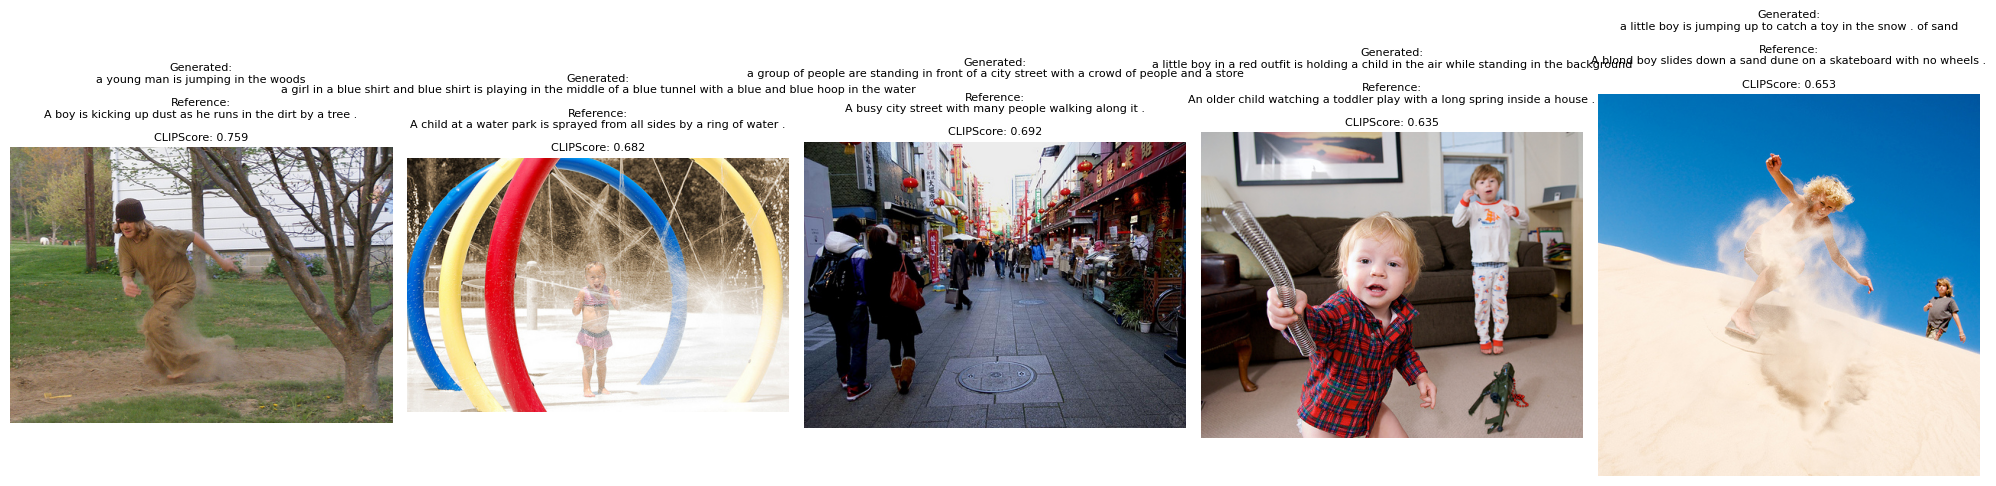

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
indices   = random.sample(range(len(val_items)), 5)

for ax, i in zip(axes, indices):
    item      = val_items[i]
    image_pil = item['image'].convert('RGB')
    caps      = [item[k] for k in CAPTION_KEYS]
    best_cap, _ = generate_caption(
        decoder, encoder, image_pil, vocab, idx2word,
        clip_model, clip_preprocess, device=device
    )
    cs = compute_clip_score(image_pil, best_cap, clip_model, clip_preprocess, device)
    ax.imshow(image_pil); ax.axis('off')
    ax.set_title(
        f'Generated:\n{best_cap}\n\nReference:\n{caps[0]}\n\nCLIPScore: {cs:.3f}',
        fontsize=8, wrap=True
    )

plt.tight_layout()
plt.savefig('final_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Baseline vs Final Comparison

In [ ]:
print('============================================')
print('         BASELINE vs FINAL MODEL           ')
print('============================================')
print(f'{"Metric":<12} {"Baseline":>10} {"Final":>10} {"Delta":>10}')
print('-' * 44)

baseline = {'BLEU-1': 0.5341, 'BLEU-4': 0.0127,
            'ROUGE-L': 0.3098, 'CLIPScore': 0.6111}
final    = {'BLEU-1': bleu1,  'BLEU-4': bleu4,
            'ROUGE-L': rougeL, 'CLIPScore': cs}

for metric in ['BLEU-1', 'BLEU-4', 'ROUGE-L', 'CLIPScore']:
    b = baseline[metric]
    f = final[metric]
    d = f - b
    arrow = 'up' if d > 0 else 'down'
    print(f'{metric:<12} {b:>10.4f} {f:>10.4f} {arrow} {abs(d):>6.4f}')

print('============================================')

         BASELINE vs FINAL MODEL           
Metric         Baseline      Final      Delta
--------------------------------------------
BLEU-1           0.5341     0.5276 down 0.0065
BLEU-4           0.0127     0.1625 up 0.1498
ROUGE-L          0.3098     0.3296 up 0.0198
CLIPScore        0.6111     0.6531 up 0.0420
